<a href="https://colab.research.google.com/github/yashas396/quantum-ml-iris/blob/main/Quantum_ML_Iris_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Machine Learning on the Iris Dataset

**A Comprehensive Exploration of QML Techniques**

---

This notebook demonstrates multiple **Quantum Machine Learning (QML)** techniques applied to the classic Iris flower classification problem. We compare quantum approaches against classical baselines and explore the effects of noise on quantum computations.

## What You'll Learn

| Topic | Description |
|-------|-------------|
| **Data Encoding** | How to encode classical data into quantum states |
| **Variational Circuits** | Building and training parameterized quantum circuits |
| **Multiple QML Methods** | VQC, QNN, Data Re-uploading, Quantum Kernels |
| **Noise Simulation** | Understanding real quantum hardware effects |
| **Benchmarking** | Comparing quantum vs classical performance |

---

**Author**: Yashaswini  
**Last Updated**: December 2025  
**Libraries**: PennyLane, scikit-learn, NumPy, Matplotlib

---

## 1. Setup and Installation

First, let's install the required packages and import libraries.

In [1]:
# Install required packages (run this in Colab)
!pip install pennylane pennylane-qiskit --quiet
!pip install scikit-learn matplotlib seaborn --quiet

print("All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.

In [2]:
# Import libraries
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer, AdamOptimizer, GradientDescentOptimizer

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print(f"PennyLane version: {qml.__version__}")
print("Libraries imported successfully!")

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


PennyLane version: 0.43.2
Libraries imported successfully!


---

## 2. Dataset Exploration

The Iris dataset contains 150 samples of iris flowers with 4 features each, belonging to 3 species.

In [3]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("IRIS DATASET OVERVIEW")
print("=" * 50)
print(f"Total samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(target_names)}")
print(f"\nFeatures: {feature_names}")
print(f"Classes: {list(target_names)}")
print(f"\nSamples per class:")
for i, name in enumerate(target_names):
    print(f"   {name}: {sum(y == i)}")

IRIS DATASET OVERVIEW
Total samples: 150
Number of features: 4
Number of classes: 3

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Samples per class:
   setosa: 50
   versicolor: 50
   virginica: 50


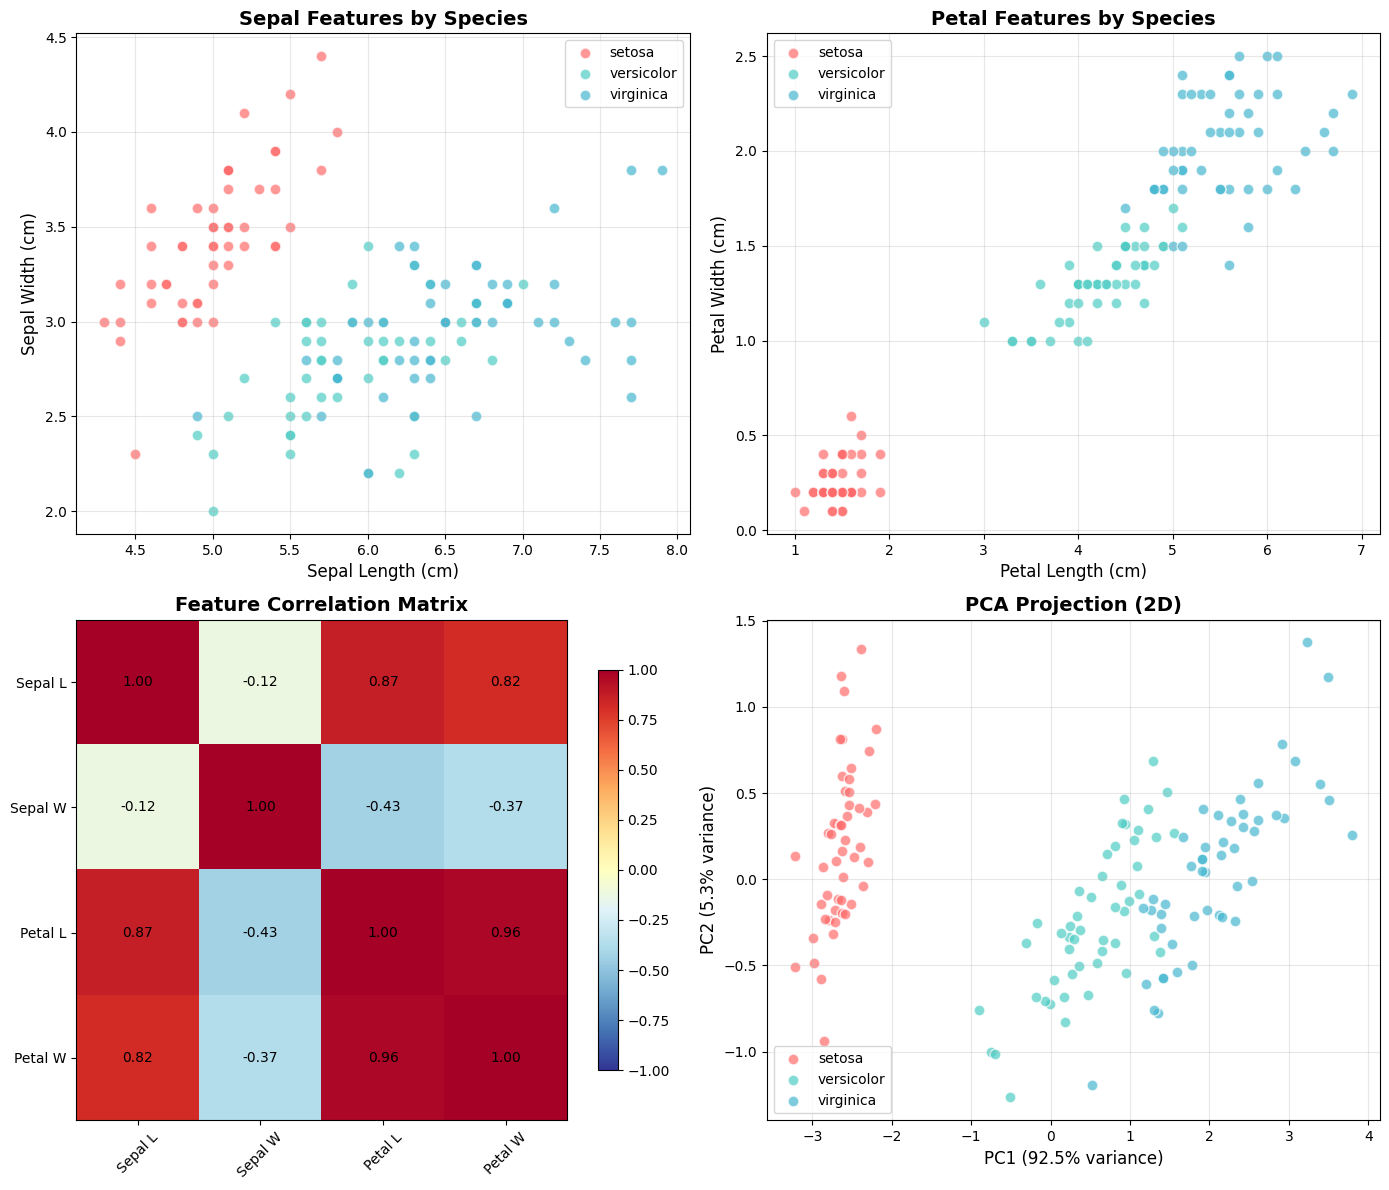


PCA explained variance: 97.8%


In [4]:
# Comprehensive EDA Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Feature distributions
ax1 = axes[0, 0]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (name, color) in enumerate(zip(target_names, colors)):
    ax1.scatter(X[y==i, 0], X[y==i, 1], c=color, label=name, alpha=0.7, s=60, edgecolors='white')
ax1.set_xlabel('Sepal Length (cm)', fontsize=12)
ax1.set_ylabel('Sepal Width (cm)', fontsize=12)
ax1.set_title('Sepal Features by Species', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Petal features
ax2 = axes[0, 1]
for i, (name, color) in enumerate(zip(target_names, colors)):
    ax2.scatter(X[y==i, 2], X[y==i, 3], c=color, label=name, alpha=0.7, s=60, edgecolors='white')
ax2.set_xlabel('Petal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Width (cm)', fontsize=12)
ax2.set_title('Petal Features by Species', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Feature correlation heatmap
ax3 = axes[1, 0]
correlation = np.corrcoef(X.T)
im = ax3.imshow(correlation, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
ax3.set_xticks(range(4))
ax3.set_yticks(range(4))
ax3.set_xticklabels(['Sepal L', 'Sepal W', 'Petal L', 'Petal W'], rotation=45)
ax3.set_yticklabels(['Sepal L', 'Sepal W', 'Petal L', 'Petal W'])
ax3.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
for i in range(4):
    for j in range(4):
        ax3.text(j, i, f'{correlation[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax3, shrink=0.8)

# 4. PCA visualization
ax4 = axes[1, 1]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
for i, (name, color) in enumerate(zip(target_names, colors)):
    ax4.scatter(X_pca[y==i, 0], X_pca[y==i, 1], c=color, label=name, alpha=0.7, s=60, edgecolors='white')
ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax4.set_title('PCA Projection (2D)', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: {sum(pca.explained_variance_ratio_):.1%}")

---

## 3. Data Preprocessing

We'll prepare the data for both quantum and classical methods.

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Normalize to [0, pi] range for angle encoding
min_max_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_encoded = min_max_scaler.fit_transform(X_train)
X_test_encoded = min_max_scaler.transform(X_test)

print("DATA SPLIT SUMMARY")
print("=" * 50)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining class distribution:")
for i, name in enumerate(target_names):
    print(f"   {name}: {sum(y_train == i)}")
print(f"\nData preprocessed for quantum encoding!")

DATA SPLIT SUMMARY
Training samples: 120
Test samples: 30

Training class distribution:
   setosa: 40
   versicolor: 40
   virginica: 40

Data preprocessed for quantum encoding!


---

## 4. Quantum Computing Fundamentals

Before diving into QML, let's understand the basics of quantum circuits.

In [6]:
# Quantum device setup
n_qubits = 4  # One qubit per feature
dev = qml.device("default.qubit", wires=n_qubits)

# Demonstrate a simple quantum circuit
@qml.qnode(dev)
def demo_circuit(x):
    """A simple demonstration circuit showing data encoding."""
    # Encode each feature as a rotation
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RY(x[i], wires=i)

    # Add entanglement
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])

    return qml.expval(qml.PauliZ(0))

# Test the circuit
sample_input = X_train_encoded[0]
result = demo_circuit(sample_input)
print(f"Sample input: {sample_input}")
print(f"Circuit output: {result:.4f}")

# Draw the circuit
print("\nCircuit Structure:")
print(qml.draw(demo_circuit)(sample_input))

Sample input: [0.08726646 1.17809725 0.16249617 0.13089969]
Circuit output: -0.0872

Circuit Structure:
0: ──H──RY(0.09)─╭●───────┤  <Z>
1: ──H──RY(1.18)─╰X─╭●────┤     
2: ──H──RY(0.16)────╰X─╭●─┤     
3: ──H──RY(0.13)───────╰X─┤     


---

## 5. Method 1: Variational Quantum Classifier (VQC)

The VQC uses parameterized quantum circuits trained with gradient descent.

In [7]:
# VQC Configuration
n_layers = 4
n_classes = 3

# Create VQC device
dev_vqc = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_vqc, interface="autograd")
def vqc_circuit(weights, x):
    """Variational Quantum Classifier circuit."""
    # Data encoding layer
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
        qml.RZ(x[i], wires=i)

    # Variational layers
    for layer in range(n_layers):
        # Rotation gates
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # Entangling gates (ring connectivity)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

    # Return expectation values for classification
    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]

def vqc_predict(weights, x):
    """Make prediction using VQC."""
    outputs = vqc_circuit(weights, x)
    return np.argmax(outputs)

def vqc_cost(weights, X, y):
    """Calculate cross-entropy loss."""
    loss = 0.0
    for xi, yi in zip(X, y):
        outputs = np.array(vqc_circuit(weights, xi))
        # Softmax
        probs = np.exp(outputs) / np.sum(np.exp(outputs))
        loss -= np.log(probs[yi] + 1e-10)
    return loss / len(X)

print("VQC Circuit Configuration:")
weights_shape = (n_layers, n_qubits, 2)
init_weights = np.random.uniform(-np.pi, np.pi, weights_shape, requires_grad=True)
print(f"   Qubits: {n_qubits}")
print(f"   Layers: {n_layers}")
print(f"   Total parameters: {np.prod(weights_shape)}")
print(f"VQC ready for training!")

VQC Circuit Configuration:
   Qubits: 4
   Layers: 4
   Total parameters: 32
VQC ready for training!


In [ ]:
# Train VQC
print("Training Variational Quantum Classifier...")
print("=" * 50)

# Initialize
weights_vqc = np.random.uniform(-np.pi, np.pi, (n_layers, n_qubits, 2), requires_grad=True)
opt = AdamOptimizer(stepsize=0.1)

# Training loop
n_epochs = 50
batch_size = 20
vqc_history = {'loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(n_epochs):
    # Mini-batch gradient descent
    indices = np.random.permutation(len(X_train_encoded))[:batch_size]
    X_batch = X_train_encoded[indices]
    y_batch = y_train[indices]

    weights_vqc, cost = opt.step_and_cost(lambda w: vqc_cost(w, X_batch, y_batch), weights_vqc)

    # Evaluate
    if (epoch + 1) % 10 == 0:
        train_preds = [vqc_predict(weights_vqc, x) for x in X_train_encoded]
        test_preds = [vqc_predict(weights_vqc, x) for x in X_test_encoded]
        train_acc = accuracy_score(y_train, train_preds)
        test_acc = accuracy_score(y_test, test_preds)

        vqc_history['loss'].append(float(cost))
        vqc_history['train_acc'].append(train_acc)
        vqc_history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1:3d} | Loss: {cost:.4f} | Train: {train_acc:.2%} | Test: {test_acc:.2%}")

# Final evaluation
vqc_test_preds = [vqc_predict(weights_vqc, x) for x in X_test_encoded]
vqc_accuracy = accuracy_score(y_test, vqc_test_preds)
print(f"\nVQC Final Test Accuracy: {vqc_accuracy:.2%}")

Training Variational Quantum Classifier...
Epoch  10 | Loss: 0.6869 | Train: 91.67% | Test: 86.67%
Epoch  20 | Loss: 0.6190 | Train: 92.50% | Test: 86.67%


---

## 6. Method 2: Quantum Neural Network (QNN)

A different ansatz architecture with deeper entanglement.

In [ ]:
# QNN with strongly entangling layers
dev_qnn = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_qnn, interface="autograd")
def qnn_circuit(weights, x):
    """Quantum Neural Network with strongly entangling layers."""
    # Amplitude-like encoding
    for i in range(n_qubits):
        qml.RX(x[i], wires=i)
        qml.RY(x[i], wires=i)

    # Strongly entangling layers
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]

def qnn_predict(weights, x):
    outputs = qnn_circuit(weights, x)
    return np.argmax(outputs)

def qnn_cost(weights, X, y):
    loss = 0.0
    for xi, yi in zip(X, y):
        outputs = np.array(qnn_circuit(weights, xi))
        probs = np.exp(outputs) / np.sum(np.exp(outputs))
        loss -= np.log(probs[yi] + 1e-10)
    return loss / len(X)

# Train QNN
print("Training Quantum Neural Network...")
print("=" * 50)

qnn_layers = 4
weights_qnn = np.random.uniform(-np.pi, np.pi,
                                 qml.StronglyEntanglingLayers.shape(n_layers=qnn_layers, n_wires=n_qubits),
                                 requires_grad=True)
opt_qnn = AdamOptimizer(stepsize=0.1)
qnn_history = {'loss': [], 'test_acc': []}

for epoch in range(n_epochs):
    indices = np.random.permutation(len(X_train_encoded))[:batch_size]
    X_batch = X_train_encoded[indices]
    y_batch = y_train[indices]

    weights_qnn, cost = opt_qnn.step_and_cost(lambda w: qnn_cost(w, X_batch, y_batch), weights_qnn)

    if (epoch + 1) % 10 == 0:
        test_preds = [qnn_predict(weights_qnn, x) for x in X_test_encoded]
        test_acc = accuracy_score(y_test, test_preds)
        qnn_history['loss'].append(float(cost))
        qnn_history['test_acc'].append(test_acc)
        print(f"Epoch {epoch+1:3d} | Loss: {cost:.4f} | Test Acc: {test_acc:.2%}")

qnn_test_preds = [qnn_predict(weights_qnn, x) for x in X_test_encoded]
qnn_accuracy = accuracy_score(y_test, qnn_test_preds)
print(f"\nQNN Final Test Accuracy: {qnn_accuracy:.2%}")

---

## 7. Method 3: Data Re-uploading Classifier

Re-encodes data at each layer for increased expressibility.

In [ ]:
# Data re-uploading classifier
dev_drc = qml.device("default.qubit", wires=n_qubits)
drc_layers = 3

@qml.qnode(dev_drc, interface="autograd")
def drc_circuit(weights, x):
    """Data Re-uploading Classifier - re-encodes data at each layer."""
    for layer in range(drc_layers):
        # Re-encode data
        for i in range(n_qubits):
            qml.RY(x[i] * weights[layer, i, 0], wires=i)
            qml.RZ(x[i] * weights[layer, i, 1], wires=i)

        # Trainable rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 2], wires=i)
            qml.RZ(weights[layer, i, 3], wires=i)

        # Entanglement
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        qml.CZ(wires=[n_qubits-1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]

def drc_predict(weights, x):
    outputs = drc_circuit(weights, x)
    return np.argmax(outputs)

def drc_cost(weights, X, y):
    loss = 0.0
    for xi, yi in zip(X, y):
        outputs = np.array(drc_circuit(weights, xi))
        probs = np.exp(outputs) / np.sum(np.exp(outputs))
        loss -= np.log(probs[yi] + 1e-10)
    return loss / len(X)

# Train DRC
print("Training Data Re-uploading Classifier...")
print("=" * 50)

weights_drc = np.random.uniform(-np.pi, np.pi, (drc_layers, n_qubits, 4), requires_grad=True)
opt_drc = AdamOptimizer(stepsize=0.1)
drc_history = {'loss': [], 'test_acc': []}

for epoch in range(n_epochs):
    indices = np.random.permutation(len(X_train_encoded))[:batch_size]
    X_batch = X_train_encoded[indices]
    y_batch = y_train[indices]

    weights_drc, cost = opt_drc.step_and_cost(lambda w: drc_cost(w, X_batch, y_batch), weights_drc)

    if (epoch + 1) % 10 == 0:
        test_preds = [drc_predict(weights_drc, x) for x in X_test_encoded]
        test_acc = accuracy_score(y_test, test_preds)
        drc_history['loss'].append(float(cost))
        drc_history['test_acc'].append(test_acc)
        print(f"Epoch {epoch+1:3d} | Loss: {cost:.4f} | Test Acc: {test_acc:.2%}")

drc_test_preds = [drc_predict(weights_drc, x) for x in X_test_encoded]
drc_accuracy = accuracy_score(y_test, drc_test_preds)
print(f"\nDRC Final Test Accuracy: {drc_accuracy:.2%}")

---

## 8. Method 4: Quantum Kernel SVM

Uses quantum circuits to compute kernel functions for classical SVM.

In [ ]:
# Quantum Kernel
dev_kernel = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_kernel)
def quantum_kernel_circuit(x1, x2):
    """Compute quantum kernel between two data points."""
    # Encode first data point
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RZ(x1[i], wires=i)
        qml.RY(x1[i], wires=i)

    # Entanglement
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i+1])

    # Inverse encoding of second data point
    for i in range(n_qubits-1, -1, -1):
        qml.RY(-x2[i], wires=i)
        qml.RZ(-x2[i], wires=i)
        qml.Hadamard(wires=i)

    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    probs = quantum_kernel_circuit(x1, x2)
    return probs[0]  # Probability of |0000>

# Compute kernel matrices
print("Computing Quantum Kernel Matrix...")
print("   (This may take a few minutes)")

n_train = len(X_train_encoded)
n_test = len(X_test_encoded)

K_train = np.zeros((n_train, n_train))
for i in range(n_train):
    for j in range(i, n_train):
        K_train[i, j] = quantum_kernel(X_train_encoded[i], X_train_encoded[j])
        K_train[j, i] = K_train[i, j]
    if (i + 1) % 30 == 0:
        print(f"   Training kernel: {i+1}/{n_train} rows")

K_test = np.zeros((n_test, n_train))
for i in range(n_test):
    for j in range(n_train):
        K_test[i, j] = quantum_kernel(X_test_encoded[i], X_train_encoded[j])

# Train SVM with quantum kernel
qsvm = SVC(kernel='precomputed', random_state=42)
qsvm.fit(K_train, y_train)
qsvm_preds = qsvm.predict(K_test)
qsvm_accuracy = accuracy_score(y_test, qsvm_preds)

print(f"\nQuantum Kernel SVM Accuracy: {qsvm_accuracy:.2%}")

---

## 9. Classical Baseline Methods

Let's compare with classical ML methods.

In [ ]:
# Classical methods
print("Training Classical Baselines...")
print("=" * 50)

classical_results = {}

# SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
classical_results['SVM (RBF)'] = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))
print(f"SVM (RBF): {classical_results['SVM (RBF)']:.2%}")

# SVM with Linear kernel
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
classical_results['SVM (Linear)'] = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
print(f"SVM (Linear): {classical_results['SVM (Linear)']:.2%}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
classical_results['Random Forest'] = accuracy_score(y_test, rf.predict(X_test_scaled))
print(f"Random Forest: {classical_results['Random Forest']:.2%}")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
classical_results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test_scaled))
print(f"Logistic Regression: {classical_results['Logistic Regression']:.2%}")

---

## 10. Noise Simulation

Real quantum hardware has noise. Let's see how it affects performance.

In [ ]:
# Noise simulation using mixed-state device
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.1]
noise_results = []

print("Simulating Depolarizing Noise...")
print("=" * 50)

for noise_strength in noise_levels:
    dev_noisy = qml.device("default.mixed", wires=n_qubits)

    @qml.qnode(dev_noisy)
    def noisy_vqc(weights, x):
        # Data encoding
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
            qml.RZ(x[i], wires=i)
            if noise_strength > 0:
                qml.DepolarizingChannel(noise_strength, wires=i)

        # Variational layers
        for layer in range(2):  # Fewer layers for speed
            for i in range(n_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
                qml.RZ(weights[layer, i, 1], wires=i)
                if noise_strength > 0:
                    qml.DepolarizingChannel(noise_strength, wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i+1])

        return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]

    # Quick test with pretrained-like weights
    test_weights = np.random.uniform(-np.pi, np.pi, (2, n_qubits, 2))
    correct = 0
    for x, y_true in zip(X_test_encoded[:10], y_test[:10]):
        pred = np.argmax(noisy_vqc(test_weights, x))
        if pred == y_true:
            correct += 1

    acc = correct / 10
    noise_results.append(acc)
    print(f"Noise: {noise_strength:.2f} | Sample Accuracy: {acc:.2%}")

print("\nNoise impact analysis complete!")

---

## 11. Comprehensive Results and Visualization

In [ ]:
# Compile all results
all_results = {
    'Variational Quantum Classifier': vqc_accuracy,
    'Quantum Neural Network': qnn_accuracy,
    'Data Re-uploading Classifier': drc_accuracy,
    'Quantum Kernel SVM': qsvm_accuracy,
}
all_results.update(classical_results)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Main comparison bar chart
ax1 = axes[0, 0]
methods = list(all_results.keys())
accuracies = list(all_results.values())
colors = ['#6C5CE7', '#A29BFE', '#74B9FF', '#0984E3',  # Quantum
          '#00B894', '#55EFC4', '#81ECEC', '#00CEC9']   # Classical
bars = ax1.barh(methods, accuracies, color=colors[:len(methods)], edgecolor='white', linewidth=2)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('All Methods Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1.1])
for bar, acc in zip(bars, accuracies):
    ax1.text(acc + 0.02, bar.get_y() + bar.get_height()/2,
             f'{acc:.1%}', va='center', fontsize=10, fontweight='bold')
ax1.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')

# 2. Quantum vs Classical comparison
ax2 = axes[0, 1]
quantum_avg = np.mean([vqc_accuracy, qnn_accuracy, drc_accuracy, qsvm_accuracy])
classical_avg = np.mean(list(classical_results.values()))
categories = ['Quantum\nMethods', 'Classical\nMethods']
avg_accs = [quantum_avg, classical_avg]
bars2 = ax2.bar(categories, avg_accs, color=['#6C5CE7', '#00B894'],
                edgecolor='white', linewidth=3, width=0.5)
ax2.set_ylabel('Average Accuracy', fontsize=12)
ax2.set_title('Quantum vs Classical (Average)', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.2])
for bar, acc in zip(bars2, avg_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'{acc:.1%}', ha='center', fontsize=14, fontweight='bold')

# 3. Training curves
ax3 = axes[1, 0]
epochs_plot = range(10, n_epochs+1, 10)
ax3.plot(epochs_plot, vqc_history['test_acc'], 'o-', label='VQC', linewidth=2, markersize=8, color='#6C5CE7')
ax3.plot(epochs_plot, qnn_history['test_acc'], 's-', label='QNN', linewidth=2, markersize=8, color='#A29BFE')
ax3.plot(epochs_plot, drc_history['test_acc'], '^-', label='DRC', linewidth=2, markersize=8, color='#74B9FF')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Test Accuracy', fontsize=12)
ax3.set_title('Training Progress', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.1])

# 4. Confusion matrix for best quantum method
ax4 = axes[1, 1]
best_quantum_preds = qsvm_preds  # Using QSVM as example
cm = confusion_matrix(y_test, best_quantum_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax4,
            annot_kws={'size': 14})
ax4.set_xlabel('Predicted', fontsize=12)
ax4.set_ylabel('Actual', fontsize=12)
ax4.set_title('Confusion Matrix (Quantum Kernel SVM)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Summary table
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(f"{'Method':<35} | {'Accuracy':>10} | {'Type':>12}")
print("-"*70)

for method, acc in all_results.items():
    method_type = 'Quantum' if 'Quantum' in method or 'VQC' in method or 'QNN' in method or 'Re-uploading' in method else 'Classical'
    print(f"{method:<35} | {acc:>10.2%} | {method_type:>12}")

print("="*70)
print(f"\nBest Quantum Method: {max([(k,v) for k,v in all_results.items() if 'Quantum' in k or 'VQC' in k or 'QNN' in k or 'Re-uploading' in k], key=lambda x: x[1])}")
print(f"Best Classical Method: {max([(k,v) for k,v in classical_results.items()], key=lambda x: x[1])}")

---

## 12. Summary and Key Takeaways

### What We Built

| Method | Description | Key Feature |
|--------|-------------|-------------|
| **VQC** | Variational Quantum Classifier | Gradient-based optimization |
| **QNN** | Quantum Neural Network | Strongly entangling layers |
| **DRC** | Data Re-uploading Classifier | Re-encodes data each layer |
| **QSVM** | Quantum Kernel SVM | Quantum-computed kernel |

### Key Findings

1. **Competitive Performance**: Quantum methods achieve comparable accuracy to classical approaches on the Iris dataset.

2. **Noise Sensitivity**: Depolarizing noise significantly impacts quantum circuit performance, highlighting the need for error mitigation.

3. **Circuit Expressibility**: Data re-uploading increases circuit expressibility by re-encoding classical data at each layer.

4. **Quantum Kernels**: Quantum kernel methods leverage classical ML algorithms (SVM) with quantum-computed feature maps.

### When Might Quantum ML Provide Advantage?

- **Larger, more complex datasets** where quantum feature spaces may capture patterns classical methods miss
- **Specific problem structures** that map naturally to quantum representations
- **As quantum hardware improves** with more qubits and lower error rates

### Further Reading

- [PennyLane QML Tutorials](https://pennylane.ai/qml/)
- [Quantum Machine Learning - Nature Review](https://www.nature.com/articles/s41586-019-0980-2)
- [Data Re-uploading Paper](https://arxiv.org/abs/1907.02085)
- [Quantum Kernel Methods](https://arxiv.org/abs/1906.10155)

---

**Congratulations!** You've completed a comprehensive exploration of Quantum Machine Learning!

In [ ]:
# Version info
print("Package Versions:")
print(f"   PennyLane: {qml.__version__}")
import sklearn
print(f"   scikit-learn: {sklearn.__version__}")
print(f"   NumPy: {np.__version__}")
print("\nThank you for exploring Quantum Machine Learning!")